In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from functools import partial
from math import log2
import matplotlib
import matplotlib.pyplot as plt
import scipy.optimize
import seaborn as sns
import torch
from torch import tensor, Tensor
from typing import Any, Literal

import block_formats.experiments as E
import block_formats.analysis as A
import block_formats.quantisation as Q

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
model = E.RequantisableModel.load("meta-llama/Llama-3.2-1B", DEVICE, torch.bfloat16)
params = {k: v.detach() for k, v in model.model.named_parameters() if v.ndim == 2}
data = E.Dataset.load_wikitext2(model.model, sequence_length=256, batch_size=16, kl_topk=128, token_limit=(256-1) * 16)

Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


## RMS moment-matching isn't optimal

It looks like Normal often needs greater scale (to cope with tails), while Student-t or Laplace sometimes need smaller scale (if they have excessive tails).

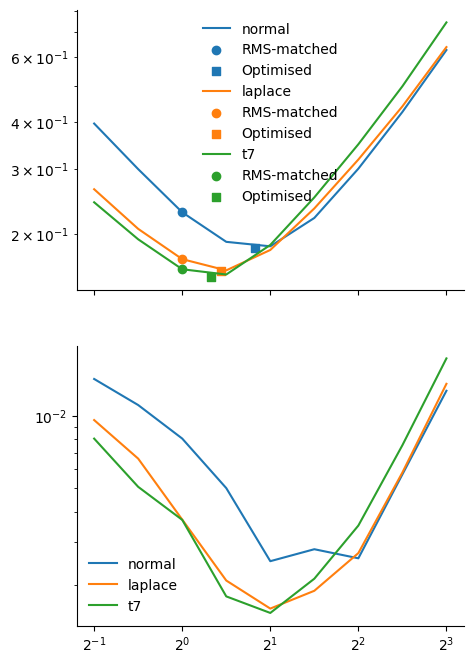

In [86]:
bits = 4
t_df = 7

model.reset()
key = "model.layers.15.self_attn.k_proj.weight"
x = params[key].float().flatten()
# x = A.Normal().sample(2**20, seed=1, device=DEVICE)
# x = A.Laplace().sample(2**20, seed=1, device=DEVICE)
# x = A.StudentT(t_df).sample(2**20, seed=1, device=DEVICE)
x = A.rms_normalise(x)

_, (ax0, ax1) = plt.subplots(nrows=2, figsize=(5, 8), sharex=True)
for (fmt, name), color in zip([
        (Q.crd_normal(bits), "normal"),
        (Q.crd_laplace(bits), "laplace"),
        (Q.crd_t(bits, t_df), f"t{t_df}"),
    ], sns.color_palette()):

    scales = tensor(2).pow(torch.arange(-1, 3+.0001, .5))
    errors = torch.stack([A.qrmse_norm(fmt, x/s) for s in scales])
    ax0.plot(scales.cpu(), errors.cpu(), label=name, color=color)

    styles = iter("os^D")
    def show(scale: float, name: str) -> None:
        ax0.scatter([float(scale)], [A.qrmse_norm(fmt, x/scale).item()], label=name, color=color, marker=next(styles))
    show(1, "RMS-matched")
    show(scipy.optimize.minimize_scalar(lambda s: A.qrmse_norm(fmt, x/s).item(), bounds=(1/4, 4), options=dict(xatol=0.01)).x, "Optimised")

    kls = []
    for scale in scales:
        model.reset()
        p = model.model.state_dict()[key]
        s = A.rms(p) * scale
        model.model.state_dict()[key][...] = fmt.quantise(p / s) * s
        kls.append(E.evaluate_model(data, model.model)["kl_div"])
    ax1.plot(scales.cpu(), kls, label=name, color=color)

for ax in [ax0, ax1]:
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.legend()

# fmt = Q.LinearScalingFormat(Q.crd_block_normal(bits, 128), Q.BFLOAT16, (128,), "absmax")
# print(A.qrmse_norm(fmt, x), fmt.count_bits(x.shape) / x.nelement())
# cfmt = Q.CompressedLUTFormat.train_grid(x, 0.25)
# print(A.qrmse_norm(cfmt, x), cfmt.count_bits_tensor(x) / x.nelement())

## Fit quantiser

In [15]:
model.reset()
key = "model.layers.0.self_attn.q_proj.weight"
x = params[key].float()
bits = 4
block_size = 64

for distribution in ["uniform", "normal", "laplace", "t"]:
    fmt = E.fit_scaled_rms_quantiser(x, bits, distribution, (None, None))
    rmse = Q.qrmse_norm(Q.LinearScalingFormat(fmt, Q.BFLOAT16, (None, None), "rms"), x)
    print(distribution, rmse.cpu(), getattr(fmt.format, "name", None))
fmt = Q.lut_lloyd_max(x, bits, 1e-4)
rmse = Q.qrmse_norm(fmt, x)
print("lloyd_max", rmse.cpu())

print()
for distribution in ["normal", "laplace", "tt"]:
    fmt = dict(normal=Q.crd_block_normal, laplace=Q.crd_block_laplace, tt=partial(Q.crd_block_t, df=20))[distribution](bits, block_size)
    rmse = Q.qrmse_norm(Q.LinearScalingFormat(fmt, Q.BFLOAT16, (1, block_size), "absmax"), x)
    print(f"block_{distribution}", rmse.cpu())

for fmt in [Q.parse("E0M3"), Q.parse("E2M1")]:
    rmse = Q.qrmse_norm(Q.LinearScalingFormat(fmt, Q.BFLOAT16, (1, block_size), "signmax"), x)
    print(f"block_{fmt}", rmse.cpu())

# Hack - use crd_block_normal() as a dummy, simply because it has range (-1, 1)
fmt = Q.lut_lloyd_max(x / Q.LinearScalingFormat(Q.crd_block_normal(bits, block_size), Q.FP32, (1, block_size), "absmax").scale_for(x),
                      bits, 1e-4)
rmse = Q.qrmse_norm(Q.LinearScalingFormat(fmt, Q.BFLOAT16, (1, block_size), "absmax"), x)
print(f"block_lloyd_max", rmse.cpu())

print()
fmt = Q.CompressedLUTFormat.train_grid(x, x.pow(2).mean().sqrt().item() * 0.25)
rmse = Q.qrmse_norm(fmt, x)
print("compressed_grid", rmse.cpu(), fmt.count_bits_tensor(x) / x.nelement())

uniform tensor(0.1766) None
normal tensor(0.1531) CRD-N-RS
laplace tensor(0.1391) CRD-L-RS
t tensor(0.1370) CRD-T[6.140605280899423]-RS
lloyd_max tensor(0.1367)

block_normal tensor(0.0940)
block_laplace tensor(0.0937)
block_tt tensor(0.0931)
block_E0M3 tensor(0.1017)
block_E2M1 tensor(0.1071)
block_lloyd_max tensor(0.0932)

compressed_grid tensor(0.0719) 3.9698610305786133
